# Book Recommender

## Imports

In [167]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import networkx as nx
from collections import defaultdict
import warnings
import os
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
from tqdm import tqdm
# warnings.filterwarnings('ignore')

## Data Loading

In [168]:
os.getcwd()

'C:\\Users\\HP\\Documents\\Projects\\recommender-systems-project'

In [169]:
books_raw = pd.read_csv('data/Books.csv', encoding='utf-8', on_bad_lines='error')
ratings_raw = pd.read_csv('data/Ratings.csv', encoding='latin-1', on_bad_lines='error')
users_raw = pd.read_csv('data/Users.csv', encoding='latin-1', on_bad_lines='error')

C:\Users\HP\AppData\Local\Temp\ipykernel_23604\3708056424.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  books_raw = pd.read_csv('data/Books.csv', encoding='utf-8', on_bad_lines='error')


### Checking the year-of-publication issue

#### Look for data types

In [170]:
type_counts = books_raw['Year-Of-Publication'].apply(type).value_counts()
print(type_counts)

Year-Of-Publication
<class 'int'>    205824
<class 'str'>     65536
Name: count, dtype: int64


#### Str types

In [171]:
strings_only = books_raw[books_raw['Year-Of-Publication'].apply(lambda x: isinstance(x, str))]
print(strings_only['Year-Of-Publication'].head())

196608    2000
196609    1995
196610    1999
196611    2004
196612    2003
Name: Year-Of-Publication, dtype: object


#### Look for non-numeric values

In [172]:
non_numeric = books_raw[books_raw['Year-Of-Publication'].apply(lambda x: isinstance(x, str) and not x.isdigit())]
print(non_numeric['Year-Of-Publication'].unique())

['DK Publishing Inc' 'Gallimard']


#### How many non-numeric values are there?

In [173]:
mismatched_counts = books_raw[books_raw['Year-Of-Publication'].isin(['DK Publishing Inc', 'Gallimard'])]['Year-Of-Publication'].value_counts()
print(mismatched_counts)

Year-Of-Publication
DK Publishing Inc    2
Gallimard            1
Name: count, dtype: int64


#### Check these non-numeric records

In [174]:
problematic_rows = books_raw[books_raw['Year-Of-Publication'].isin(['DK Publishing Inc', 'Gallimard'])]
problematic_rows

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
209538,078946697X,"DK Readers: Creating the X-Men, How It All Beg...",2000,DK Publishing Inc,http://images.amazon.com/images/P/078946697X.0...,http://images.amazon.com/images/P/078946697X.0...,http://images.amazon.com/images/P/078946697X.0...,NaN
220731,2070426769,"Peuple du ciel, suivi de 'Les Bergers\"";Jean-M...",2003,Gallimard,http://images.amazon.com/images/P/2070426769.0...,http://images.amazon.com/images/P/2070426769.0...,http://images.amazon.com/images/P/2070426769.0...,NaN
221678,0789466953,"DK Readers: Creating the X-Men, How Comic Book...",2000,DK Publishing Inc,http://images.amazon.com/images/P/0789466953.0...,http://images.amazon.com/images/P/0789466953.0...,http://images.amazon.com/images/P/0789466953.0...,NaN


#### Fix the problematic records

In [175]:
# Fix the first 'DK Publishing Inc' record (index 209538)
books_raw.loc[209538, 'Book-Title'] = "DK Readers: Creating the X-Men, How It All Began (Level 4: Proficient Readers)"
books_raw.loc[209538, 'Book-Author'] = "Michael Teitelbaum"
books_raw.loc[209538, 'Year-Of-Publication'] = 2000
books_raw.loc[209538, 'Publisher'] = "DK Publishing Inc"

# Fix the 'Gallimard' record (index 220731)
books_raw.loc[220731, 'Book-Title'] = "Peuple du ciel, suivi de 'Les Bergers'"
books_raw.loc[220731, 'Book-Author'] = "Jean-Marie Gustave Le Clézio"
books_raw.loc[220731, 'Year-Of-Publication'] = 2003
books_raw.loc[220731, 'Publisher'] = "Gallimard"

# Fix the second 'DK Publishing Inc' record (index 221678)
books_raw.loc[221678, 'Book-Title'] = "DK Readers: Creating the X-Men, How Comic Books Come to Life (Level 4: Proficient Readers)"
books_raw.loc[221678, 'Book-Author'] = "James Buckley"
books_raw.loc[221678, 'Year-Of-Publication'] = 2000
books_raw.loc[221678, 'Publisher'] = "DK Publishing Inc"

#### Parse the year-of-publication column to numeric

In [176]:
books_raw['Year-Of-Publication'] = pd.to_numeric(books_raw['Year-Of-Publication'], errors='raise')
print(books_raw['Year-Of-Publication'].dtype)

int64


## Data Analysis

In [177]:
print("BOOKS DATAFRAME INFO:")
print(books_raw.info())

print("\nRATINGS DATAFRAME INFO:")
print(ratings_raw.info())

print("\nUSERS DATAFRAME INFO:")
print(users_raw.info())

BOOKS DATAFRAME INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271360 entries, 0 to 271359
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   ISBN                 271360 non-null  object
 1   Book-Title           271360 non-null  object
 2   Book-Author          271358 non-null  object
 3   Year-Of-Publication  271360 non-null  int64 
 4   Publisher            271358 non-null  object
 5   Image-URL-S          271360 non-null  object
 6   Image-URL-M          271360 non-null  object
 7   Image-URL-L          271357 non-null  object
dtypes: int64(1), object(7)
memory usage: 16.6+ MB
None

RATINGS DATAFRAME INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1149780 entries, 0 to 1149779
Data columns (total 3 columns):
 #   Column       Non-Null Count    Dtype 
---  ------       --------------    ----- 
 0   User-ID      1149780 non-null  int64 
 1   ISBN         1149780 non-null  object
 2 

### Books

In [178]:
books_raw.describe()

,Year-Of-Publication
count,271360.000000
mean,1959.761273
std,257.992836
min,0.000000
25%,1989.000000
50%,1995.000000
75%,2000.000000
max,2050.000000


#### Outliers

In [179]:
print(f"0: {(books_raw['Year-Of-Publication'] == 0).sum()}")
print(f"Before 1900 (non-zero): {((books_raw['Year-Of-Publication'] < 1900) & (books_raw['Year-Of-Publication'] > 0)).sum()}")
print(f"After 2004: {(books_raw['Year-Of-Publication'] > 2004).sum()}")
print(f"After 2025: {(books_raw['Year-Of-Publication'] > 2025).sum()}")

0: 4618
Before 1900 (non-zero): 4
After 2004: 72
After 2025: 12


> NOTE: dataset is made in 2004, so any book published after 2004 is an error.

#### Books before 1900 but non-zero

In [180]:
books_raw[(books_raw['Year-Of-Publication'] < 1900) & (books_raw['Year-Of-Publication'] > 0)][['Book-Title', 'Book-Author', 'Year-Of-Publication']]

,Book-Title,Book-Author,Year-Of-Publication
171817,"Complete Works 10 Volumes [2,6,7,8,9] (Notable...",Benjamin Franklin,1806
227531,Dalan-i bihisht (Dastan-i Irani),Nazi Safavi,1378
245607,"Hugh Wynne, Free Quaker (2 Volumes (BCL1-PS Am...",Silas Weir Mitchell,1897
253750,Tasht-i khun,IsmaÂ°il Fasih,1376


> 171817, 245607 seems to be correct; other two are errors

#### Filtering out the outliers

In [181]:
books_clean = books_raw[(books_raw['Year-Of-Publication'] > 1800) & 
                           (books_raw['Year-Of-Publication'] <= 2004)].copy()
books_outliers_isbns = books_raw[~books_raw.index.isin(books_clean.index)]['ISBN'].tolist()
print(f"{len(books_raw) - len(books_clean)} outliers removed. Remaining books: {len(books_clean)}")
print(f"Outlier ISBNs length: {len(books_outliers_isbns)}")
print(f"Sample outlier ISBNs: {books_outliers_isbns[:5]}")

4692 outliers removed. Remaining books: 266668
Outlier ISBNs length: 4692
Sample outlier ISBNs: ['3150000335', '342311360X', '0571197639', '3596214629', '8845229041']


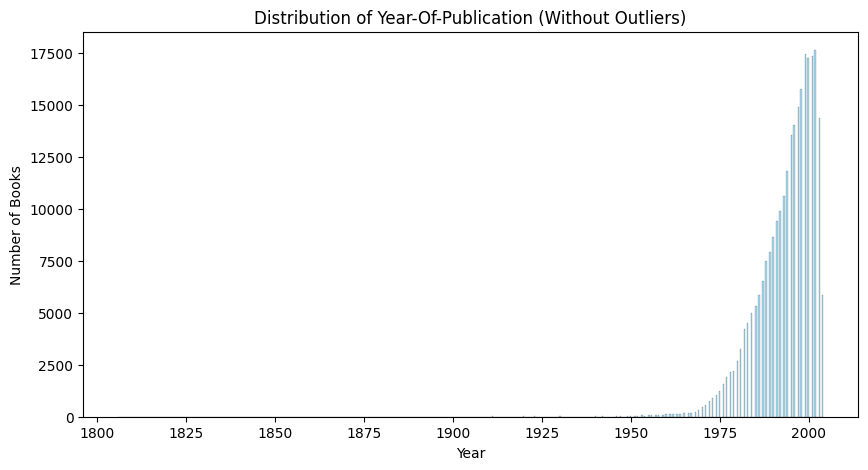

In [182]:
plt.figure(figsize=(10, 5))
sns.histplot(books_clean['Year-Of-Publication'], bins=500, kde=False, color='skyblue') # type: ignore
plt.title('Distribution of Year-Of-Publication (Without Outliers)')
plt.xlabel('Year')
plt.ylabel('Number of Books')
plt.show()

### Users

#### Check age

In [183]:
users_raw.describe()

,User-ID,Age
count,278858.00000,168096.000000
mean,139429.50000,34.751434
std,80499.51502,14.428097
min,1.00000,0.000000
25%,69715.25000,24.000000
50%,139429.50000,32.000000
75%,209143.75000,44.000000
max,278858.00000,244.000000


#### Handle outliers

In [184]:
users_clean = users_raw[(users_raw['Age'] > 0) & (users_raw['Age'] < 120)].copy()
print(f"Original users: {len(users_raw):,}")
print(f"Cleaned users (valid ages): {len(users_clean):,}")
print(f"Removed {len(users_raw) - len(users_clean):,} users with invalid ages.")

Original users: 278,858
Cleaned users (valid ages): 167,602
Removed 111,256 users with invalid ages.


#### Hist age

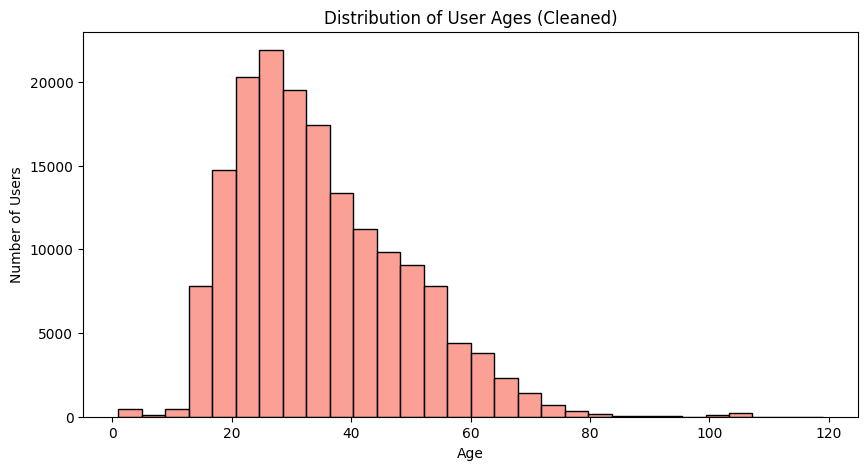

In [185]:
plt.figure(figsize=(10, 5))
sns.histplot(users_clean['Age'], bins=30, kde=False, color='salmon') # type: ignore
plt.title('Distribution of User Ages (Cleaned)')
plt.xlabel('Age')
plt.ylabel('Number of Users')
plt.show()

#### Extract country from location

In [186]:
users_clean['Country'] = users_clean['Location'].apply(
    lambda x: x.split(',')[-1].strip().lower() if pd.notna(x) else 'unknown'
)
print(f"Country counts: {users_clean['Country'].value_counts().head(10)}")

Country counts: Country
usa               76322
spain             12552
united kingdom    12490
canada            11354
germany           10600
australia          8857
italy              5359
france             3000
portugal           2658
new zealand        2000
Name: count, dtype: int64


### Ratings

In [187]:
ratings_raw.describe()

,User-ID,Book-Rating
count,1.149780e+06,1.149780e+06
mean,1.403864e+05,2.866950e+00
std,8.056228e+04,3.854184e+00
min,2.000000e+00,0.000000e+00
25%,7.034500e+04,0.000000e+00
50%,1.410100e+05,0.000000e+00
75%,2.110280e+05,7.000000e+00
max,2.788540e+05,1.000000e+01


> As per dataset description in kaggle, ratings 1-10 says the user has rated, while 0 means the user has not rated the book. So we will filter out the records with rating 0.

#### Check for interactions with outlier books

In [188]:
ratings_clean_all_interactions = ratings_raw[ratings_raw['ISBN'].isin(books_clean['ISBN'])].copy()

print(f"Original ratings: {len(ratings_raw):,}")
print(f"Cleaned ratings: {len(ratings_clean_all_interactions):,}")
print(f"Removed {len(ratings_raw) - len(ratings_clean_all_interactions):,} outlier interactions.")

Original ratings: 1,149,780
Cleaned ratings: 1,016,920
Removed 132,860 outlier interactions.


#### Select only rated interactions

In [189]:
ratings_clean_with_invalid_users = ratings_clean_all_interactions[ratings_clean_all_interactions['Book-Rating'] > 0].copy()
print(f"Original ratings: {len(ratings_clean_all_interactions):,}")
print(f"Cleaned ratings (only rated interactions): {len(ratings_clean_with_invalid_users):,}")
print(f"Removed {len(ratings_clean_all_interactions) - len(ratings_clean_with_invalid_users):,} unrated interactions.")

Original ratings: 1,016,920
Cleaned ratings (only rated interactions): 377,972
Removed 638,948 unrated interactions.


> NOTE: extremely difficult to say how the interaction of a person with a book without rating. It can be positive, negative, or neutral. So we will filter out the records with rating 0, which means the user has not rated the book. A good judgement cannot be made without being biased.

#### Select ratings with valid users

In [190]:
ratings_clean = ratings_clean_with_invalid_users[ratings_clean_with_invalid_users['User-ID'].isin(users_clean['User-ID'])].copy()
print(f"Original ratings: {len(ratings_clean_with_invalid_users):,}")
print(f"Cleaned ratings (only valid users): {len(ratings_clean):,}")
print(f"Removed {len(ratings_clean_with_invalid_users) - len(ratings_clean):,} ratings from invalid users.")

Original ratings: 377,972
Cleaned ratings (only valid users): 264,919
Removed 113,053 ratings from invalid users.


#### Hist of ratings

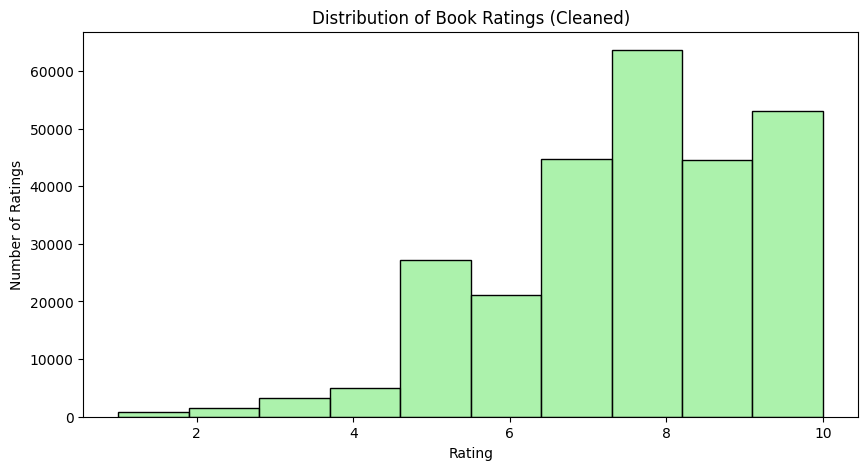

In [191]:
plt.figure(figsize=(10, 5))
sns.histplot(ratings_clean['Book-Rating'], bins=10, kde=False, color='lightgreen') # type: ignore
plt.title('Distribution of Book Ratings (Cleaned)')
plt.xlabel('Rating')
plt.ylabel('Number of Ratings')
plt.show()

#### Users with no ratings

In [192]:
users_with_ratings = ratings_clean['User-ID'].unique()
users_no_ratings = users_clean[~users_clean['User-ID'].isin(users_with_ratings)]
print(f"Users with ratings: {len(users_with_ratings):,}")
print(f"Users with no ratings: {len(users_no_ratings):,}")
print(f"Total users: {len(users_clean):,}")

Users with ratings: 39,785
Users with no ratings: 127,817
Total users: 167,602


#### Books with no ratings

In [193]:
books_with_ratings = ratings_clean['ISBN'].unique()
books_no_ratings = books_clean[~books_clean['ISBN'].isin(books_with_ratings)]
print(f"Books with ratings: {len(books_with_ratings):,}")
print(f"Books with no ratings: {len(books_no_ratings):,}")
print(f"Total books: {len(books_clean):,}")

Books with ratings: 117,600
Books with no ratings: 149,068
Total books: 266,668


> No rating ones are cold-start; but removed here because we cannot evaluate them. 

#### Books title cleanup

In [194]:
books_clean['Book-Author'] = books_clean['Book-Author'].str.title()
books_clean['Book-Title'] = books_clean['Book-Title'].str.title()

## Data Split

#### Downsampling to prevent OOM

In [195]:
top_users = ratings_clean['User-ID'].value_counts().head(1000).index
top_books = ratings_clean['ISBN'].value_counts().head(2000).index

sampled_ratings = ratings_clean[
    ratings_clean['User-ID'].isin(top_users) &
    ratings_clean['ISBN'].isin(top_books)
].copy()

# Select only the users and books that are in the sampled ratings
final_isbns = set(sampled_ratings['ISBN'])
final_users = set(sampled_ratings['User-ID'])

books_sampled = books_clean[books_clean['ISBN'].isin(final_isbns)].reset_index(drop=True)
users_sampled = users_clean[users_clean['User-ID'].isin(final_users)].reset_index(drop=True)

print(f"Sampled Dataset -> Users: {len(users_sampled)}, Books: {len(books_sampled)}")

Sampled Dataset -> Users: 975, Books: 1991


#### User-based split

In [196]:
train_data = []
test_data = []

for user_id, group in sampled_ratings.groupby('User-ID'):
    if len(group) <= 1:
        # If the user only has 1 rating, it must go to training
        train_data.append(group)
    else:
        # Otherwise, split 80/20 for this specific user
        u_train, u_test = train_test_split(group, test_size=0.2, random_state=42)   # ceils the test, so even 2 ratings: 20% of 2 = 0.4 -> 1 rating in test, remaining 1 in train
        train_data.append(u_train)
        test_data.append(u_test)

train_ratings = pd.concat(train_data, ignore_index=True)    # flatten list of dataframes into one dataframe
test_ratings = pd.concat(test_data, ignore_index=True)  

print(f"Training on {len(train_ratings)} interactions.")
print(f"Testing on {len(test_ratings)} interactions.")

Training on 17368 interactions.
Testing on 4815 interactions.


## Feature Engineering

### 1. Content based features (TF-IDF on book titles)

If you like `book A`, you might like `book B` because they have similar titles (e.g. same author, same year, same title). We can capture this similarity by applying TF-IDF vectorization on the book titles and then computing cosine similarity between the resulting vectors.

> Can capture very niche taste of users who like specific authors or specific series of books. But cannot capture general taste of users who like a genre but not specific authors.

Building Content-Based Features (TF-IDF)...
✓ Content-Based Features built successfully.

Sample TF-IDF features for first 5 books:

Book: The Testament by John Grisham (1999)
Top TF-IDF features: ['1996', '1999', 'john', 'grisham', 'john grisham']

Book: Beloved (Plume Contemporary Fiction) by Toni Morrison (1994)
Top TF-IDF features: ['year', '1997', '1996', '1994', 'fiction']

Book: Wild Animus by Rich Shapero (2004)
Top TF-IDF features: ['1997', '1996', 'unfortunate events', 'allende', '2004']

Book: Airframe by Michael Crichton (1997)
Top TF-IDF features: ['unfortunate events', '1997', 'michael', 'crichton', 'michael crichton']

Book: Timeline by Michael Crichton (2000)
Top TF-IDF features: ['unfortunate events', '2000', 'michael', 'crichton', 'michael crichton']


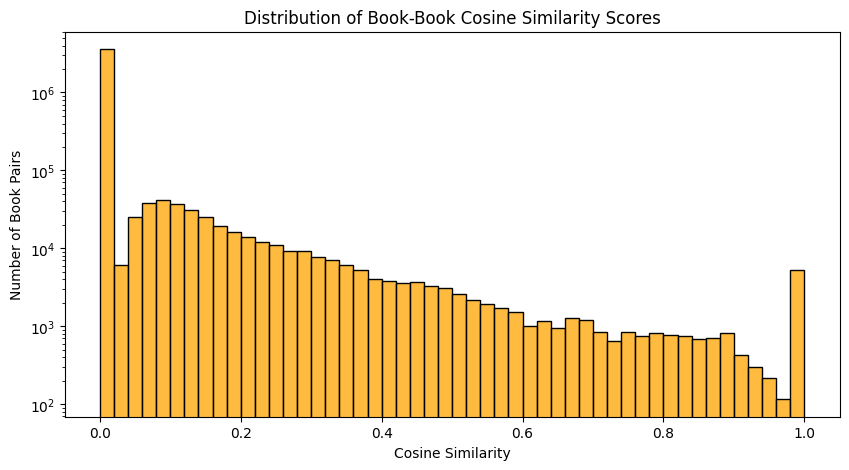

In [197]:
print("Building Content-Based Features (TF-IDF)...")
# Combine text features for TF-IDF
books_sampled['content'] = (
    books_sampled['Book-Title'].fillna('') + ' ' +
    books_sampled['Book-Author'].fillna('') + ' ' +
    books_sampled['Year-Of-Publication'].astype(str)
)

tfidf_vectorizer = TfidfVectorizer(max_features=500, stop_words='english', ngram_range=(1, 2))  # consider single word and word pairs (bigrams); names are bigrams
item_profiles = tfidf_vectorizer.fit_transform(books_sampled['content'])    # shape = (num_books, max_features); each row is a book, each column is a TF-IDF feature
# Similar books (same title, same author, same year) = similar TF-IDF profiles -> cosine similarity between item_profiles rows
print("✓ Content-Based Features built successfully.")

# Sample of the TF-IDF features for the first 5 books
feature_names = tfidf_vectorizer.get_feature_names_out()
print("\nSample TF-IDF features for first 5 books:")
for i in range(5):
    print(f"\nBook: {books_sampled.loc[i, 'Book-Title']} by {books_sampled.loc[i, 'Book-Author']} ({books_sampled.loc[i, 'Year-Of-Publication']})")
    top_indices = np.argsort(item_profiles[i].toarray()[0])[-5:]  # get indices of top 5 features for this book
    top_features = [feature_names[idx] for idx in top_indices]
    print(f"Top TF-IDF features: {top_features}")

# visulize the book similarity distribution for all books
book_similarity_matrix = cosine_similarity(item_profiles)  # shape = (num_books, num_books); each entry [i,j] is the cosine similarity between book i and book j
plt.figure(figsize=(10, 5))
sns.histplot(book_similarity_matrix.flatten(), bins=50, kde=False, color='orange') # type: ignore
plt.title('Distribution of Book-Book Cosine Similarity Scores')
plt.yscale('log')
plt.xlabel('Cosine Similarity')
plt.ylabel('Number of Book Pairs')
plt.show()


### 2. Collaborative Filtering Features

If you like `book A`, you might like `book B` because other users who liked `book A` also liked `book B`. We can capture this similarity by creating a user-item matrix from the training ratings, where rows represent users, columns represent books, and values represent the ratings. This matrix can then be used to compute user-user or item-item similarities for collaborative filtering.

> Can capture general taste of users who like a genre but not specific authors. But cannot capture very niche taste of users who like specific authors or specific series of books.

Building Collaborative Filtering Features (User-Item Matrix)...
Calculating user-user cosine similarity matrix...
✓ Collaborative Filtering Features built successfully.

Sample User Similarity Matrix (first 5 users):
User-ID  254   638   1733  1903  2030
User-ID                              
254       1.0   0.0   0.0   0.0   0.0
638       0.0   1.0   0.0   0.0   0.0
1733      0.0   0.0   1.0   0.0   0.0
1903      0.0   0.0   0.0   1.0   0.0
2030      0.0   0.0   0.0   0.0   1.0


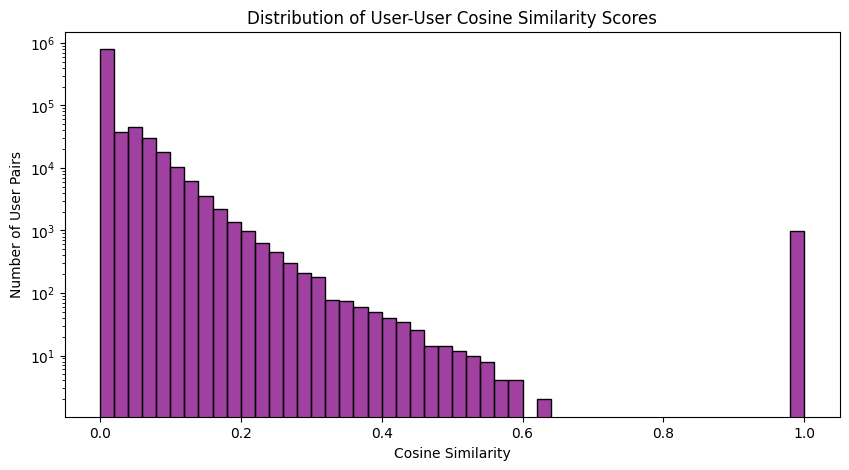

In [198]:
print("Building Collaborative Filtering Features (User-Item Matrix)...")
user_item_matrix = train_ratings.pivot_table(
    index='User-ID', columns='ISBN', values='Book-Rating', fill_value=0
)   # rows = users, columns = books, values = ratings; fill missing ratings with 0 (unrated)

# Compute Cosine Similarity between users
print("Calculating user-user cosine similarity matrix...")
user_similarity_matrix = pd.DataFrame(
    cosine_similarity(user_item_matrix),
    index=user_item_matrix.index,
    columns=user_item_matrix.index
)   # shape = (num_users, num_users); each entry (i,j) is the cosine similarity between user i and user j based on their ratings
print("✓ Collaborative Filtering Features built successfully.")

# Sample of the user similarity matrix for the first 5 users
print("\nSample User Similarity Matrix (first 5 users):")
print(user_similarity_matrix.iloc[:5, :5])

# Visualize the distribution of user-user cosine similarity scores
plt.figure(figsize=(10, 5))
sns.histplot(user_similarity_matrix.values.flatten(), bins=50, kde=False, color='purple') # type: ignore
plt.title('Distribution of User-User Cosine Similarity Scores')
plt.yscale('log')
plt.xlabel('Cosine Similarity')
plt.ylabel('Number of User Pairs')
plt.show()

### 3. Network based features for popularity

Identify popular books (`best sellers`) based on the book-user interaction graph.

Building Network Features...
Calculating PageRank scores for items...
✓ Popular item features built successfully.

Sample Item Popularity Scores (first 5 books):
Book: The Testament by John Grisham (1999) - PageRank Popularity Score: 0.000502
Book: Beloved (Plume Contemporary Fiction) by Toni Morrison (1994) - PageRank Popularity Score: 0.000403
Book: Wild Animus by Rich Shapero (2004) - PageRank Popularity Score: 0.000630
Book: Airframe by Michael Crichton (1997) - PageRank Popularity Score: 0.000244
Book: Timeline by Michael Crichton (2000) - PageRank Popularity Score: 0.000693


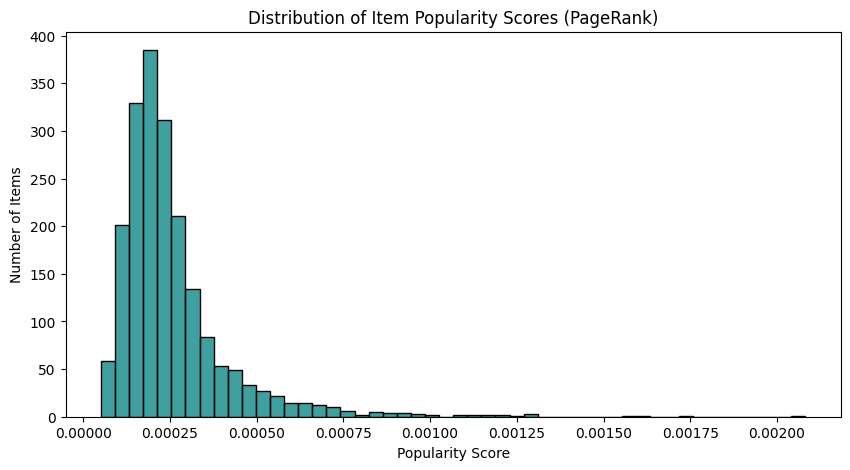

In [199]:
print("Building Network Features...")
bipartite_graph = nx.Graph()    # two separate parties: users and items; edges represent interactions (ratings) between them

# Add nodes and edges
for user_id in train_ratings['User-ID'].unique():   # type: ignore
    bipartite_graph.add_node(f"U{user_id}", node_type='user')
for isbn in books_sampled['ISBN'].unique():
    bipartite_graph.add_node(f"I{isbn}", node_type='item')
for _, row in train_ratings.iterrows():  # type: ignore
    if f"U{row['User-ID']}" in bipartite_graph.nodes() and f"I{row['ISBN']}" in bipartite_graph.nodes():
        bipartite_graph.add_edge(f"U{row['User-ID']}", f"I{row['ISBN']}", weight=row['Book-Rating'])    # weighted by rating (stronger connection for higher ratings)

# Calculate global popularity via PageRank
print("Calculating PageRank scores for items...")
pagerank_scores = nx.pagerank(bipartite_graph, weight='weight', max_iter=50)
item_popularity = {k.replace('I', ''): v for k, v in pagerank_scores.items() if k.startswith('I')}  # Extract only books; not users

print("✓ Popular item features built successfully.")

# Sample of the item popularity scores for the first 5 books
print("\nSample Item Popularity Scores (first 5 books):")
for i in range(5):
    isbn = books_sampled.loc[i, 'ISBN']
    popularity_score = item_popularity.get(isbn, 0)
    print(f"Book: {books_sampled.loc[i, 'Book-Title']} by {books_sampled.loc[i, 'Book-Author']} ({books_sampled.loc[i, 'Year-Of-Publication']}) - PageRank Popularity Score: {popularity_score:.6f}")

# visualize the distribution of item popularity scores
plt.figure(figsize=(10, 5))
sns.histplot(list(item_popularity.values()), bins=50, kde=False, color='teal') # type: ignore
plt.title('Distribution of Item Popularity Scores (PageRank)')
plt.xlabel('Popularity Score')
plt.ylabel('Number of Items')
plt.show()

## Recommendation Logic

### 1. User based collaborative filtering

- Step 1: Find users most similar to target user
- Step 2: Get books those similar users rated highly
- Step 3: Weight by similarity (if User B is 90% similar, their ratings matter more)
- Step 4: Normalize to 0-1 range

In [200]:
def get_collaborative_scores(user_id, exclude_isbns):
    """User-based CF: Finds similar users and weights their ratings."""
    if user_id not in user_similarity_matrix.index:
        return {}
    
    # Top 5 similar users (excluding the user themselves)
    similar_users = user_similarity_matrix[user_id].sort_values(ascending=False)[1:6]
    scores = defaultdict(float)
    
    for sim_user, similarity in similar_users.items():
        if similarity <= 0 or sim_user not in user_item_matrix.index:
            continue
            
        sim_user_ratings = user_item_matrix.loc[sim_user]
        for isbn, rating in sim_user_ratings.items():   # type: ignore
            if rating > 0 and isbn not in exclude_isbns:
                scores[isbn] += similarity * rating
                
    if scores:
        max_score = max(scores.values())
        scores = {k: v/max_score for k, v in scores.items()} # Normalize
    return scores

### 2. Content based filtering (user history on book titles)

- Step 1: Identify books user liked (rating ≥7)
- Step 2: Create "user profile" = average of these books' TF-IDF vectors
- Step 3: Calculate cosine similarity between profile and all other books
- Step 4: Books similar to user's favourites score high

*Example:*

- User liked: "Harry Potter" (fantasy, wizard, magic)
- Their profile learns: likes fantasy books with magic
- System recommends: "Percy Jackson" (similar fantasy)

In [201]:
def get_content_scores(user_id, exclude_isbns):
    """Content-based: Recommends books similar to those the user rated highly."""
    user_ratings = train_ratings[train_ratings['User-ID'] == user_id]
    liked_isbns = user_ratings[user_ratings['Book-Rating'] >= 7]['ISBN'].values
    
    if len(liked_isbns) == 0:
        return {}
        
    liked_indices = books_sampled.index[books_sampled['ISBN'].isin(liked_isbns)].tolist()
    if not liked_indices:
        return {}
        
    # Create an average profile of what the user likes
    user_profile = np.asarray(item_profiles[liked_indices].mean(axis=0))    # type: ignore
    similarities = cosine_similarity(user_profile, item_profiles)[0]    # items_profiles we precomputed before for all books
    
    scores = {}
    for idx, isbn in enumerate(books_sampled['ISBN']):
        if isbn not in exclude_isbns:
            scores[isbn] = similarities[idx]
    return scores

### 3. Personalization of scores

- Young users (age <30) prefer recent books → +15% boost for books after 2000
- Older users (age >40) prefer classics → +10% boost for books before 1990

In [202]:
def apply_demographic_personalization(user_id, scores):
    """Boosts scores based on user Age and Book Publication Year."""
    if user_id not in users_sampled['User-ID'].values:
        return scores

    age = users_sampled.loc[users_sampled['User-ID'] == user_id, 'Age'].values[0]   # type: ignore
    personalized = {}

    for isbn, score in scores.items():
        if isbn not in books_sampled['ISBN'].values:
            personalized[isbn] = score
            continue

        book_year = books_sampled.loc[books_sampled['ISBN'] == isbn, 'Year-Of-Publication'].values[0] # type: ignore
        boost = 1.0
        
        if pd.notna(age):
            if age < 30 and book_year >= 2000:
                boost = 1.15  # Younger readers might prefer newer books
            elif age > 40 and book_year <= 1990:
                boost = 1.10  # Older readers might appreciate classics

        personalized[isbn] = score * boost
    return personalized

### 4. Recommender router

#### For cold-start users

- Can't use collaborative filtering (not enough ratings to find similar users)
- Use content-based (find books similar to their few rated books)
- Boost with popularity (safe default for new users)

#### For warm users

- User CF is stronger (they have enough history to find similar users)
- Content adds personal taste nuance
- Personalization boosts relevant demographics

In [203]:
COLD_START_THRESHOLD = 3

def recommend_books(user_id, n=10):
    """Main routing function: Handles Cold-Start vs Warm users."""
    user_ratings = train_ratings[train_ratings['User-ID'] == user_id]
    rated_isbns = user_ratings['ISBN'].values
    
    # 1. COLD START STRATEGY (Popularity + Content)
    if len(user_ratings) <= COLD_START_THRESHOLD:
        scores = get_content_scores(user_id, rated_isbns)
        
        # Merge with popularity if content scores are weak
        for isbn in books_sampled['ISBN']:
            if isbn not in rated_isbns:
                pop_score = item_popularity.get(isbn, 0) * 100
                scores[isbn] = 0.7 * scores.get(isbn, 0) + 0.3 * pop_score
                
        scores = apply_demographic_personalization(user_id, scores)
        sorted_items = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:n]
        return [isbn for isbn, _ in sorted_items]

    # 2. HYBRID STRATEGY (Warm Users)
    cf_scores = get_collaborative_scores(user_id, rated_isbns)
    content_scores = get_content_scores(user_id, rated_isbns)
    
    hybrid_scores = {}
    all_isbns = set(cf_scores.keys()) | set(content_scores.keys())
    
    for isbn in all_isbns:
        cf = cf_scores.get(isbn, 0)
        content = content_scores.get(isbn, 0)
        # Weighted hybrid
        hybrid_scores[isbn] = (0.7 * cf) + (0.3 * content)
        
    hybrid_scores = apply_demographic_personalization(user_id, hybrid_scores)
    sorted_items = sorted(hybrid_scores.items(), key=lambda x: x[1], reverse=True)[:n]
    return [isbn for isbn, _ in sorted_items]

### Algorithms Summary

| **Algorithm**               	| **Location**                        	| **When Used**           	| **Why**                                       	|
|-----------------------------	|-------------------------------------	|-------------------------	|-----------------------------------------------	|
| Content-Based (TF-IDF)      	| get_content_scores()                	| All users               	| Recommend books similar to what they liked    	|
| Collaborative Filtering     	| get_collaborative_scores()          	| Warm users (>3 ratings) 	| Find similar users, recommend what they liked 	|
| Network Analysis (PageRank) 	| item_popularity calculation         	| Combined in hybrid      	| Identify popular/important books              	|
| Hybrid                      	| recommend_books()                   	| Warm users              	| Combine CF (70%) + Content (30%)              	|
| Cold-Start Strategy         	| recommend_books() logic             	| New users (≤3 ratings)  	| Content (70%) + Popularity (30%)              	|
| Personalization             	| apply_demographic_personalization() 	| All users               	| Boost based on age + book year                	|

## Evaluation and Baseline

- Precision@10: Of top 10 recommendations, how many did user actually like?
- Recall@10: Of all books user liked, how many did you find?
- NDCG@10: Ideal ranking metric (position matters)
- Hit Rate@10: Did you get at least 1 correct?
- Personalization: How different are the recommendation lists across users? (higher is more personalized)
- Coverage: What % of all books is recommended overall? (higher is better coverage)

### Evaluation Logic

In [212]:
def calculate_ndcg(recommended, relevant, k):
    dcg = sum([1.0 / np.log2(i + 2) for i, isbn in enumerate(recommended[:k]) if isbn in relevant])
    idcg = sum([1.0 / np.log2(i + 2) for i in range(min(len(relevant), k))])
    return dcg / idcg if idcg > 0 else 0.0

def evaluate_model(recommend_func, k=10, n_users=50):
    test_users = test_ratings['User-ID'].unique()
    if n_users < 0 or n_users >= len(test_users):
        eval_users = test_users
    else:
        eval_users = np.random.choice(test_users, n_users, replace=False)
    
    precision_scores, recall_scores, ndcg_scores, hit_scores = [], [], [], []
    all_recommended_lists = []  # For Personalization metric
    unique_recommended_items = set()  # For Coverage metric
    
    for user_id in tqdm(eval_users):
        user_test = test_ratings[test_ratings['User-ID'] == user_id]
        relevant_items = set(user_test['ISBN'].values)
        if not relevant_items:
            continue
            
        recommended_items = recommend_func(user_id, n=k)
        recommended_set = set(recommended_items)
        
        # Track for advanced metrics
        all_recommended_lists.append(recommended_items)
        unique_recommended_items.update(recommended_items)
        
        # Standard metrics
        if len(recommended_items) > 0:
            precision_scores.append(len(recommended_set & relevant_items) / len(recommended_items))
        recall_scores.append(len(recommended_set & relevant_items) / len(relevant_items) if len(relevant_items) > 0 else 0.0)
        hit_scores.append(1.0 if len(recommended_set & relevant_items) > 0 else 0.0)
        ndcg_scores.append(calculate_ndcg(recommended_items, relevant_items, k))
    
    # --- ADVANCED METRICS CALCULATIONS ---
    # 1. Catalog Coverage: % of available items recommended
    total_catalog_size = len(books_sampled['ISBN'].unique())
    coverage = len(unique_recommended_items) / total_catalog_size if total_catalog_size > 0 else 0
    
    # 2. Personalization: 1 - average overlap between users' lists
    if len(all_recommended_lists) > 1:
        overlaps = []
        # Compare every user's list with every other user's list
        for list1, list2 in itertools.combinations(all_recommended_lists, 2):
            overlap = len(set(list1) & set(list2)) / k
            overlaps.append(overlap)
        personalization = 1.0 - np.mean(overlaps)
    else:
        personalization = 0.0 # If only one user, we can't measure personalization
        
    return {
        f'Precision@{k}': np.mean(precision_scores),
        f'Recall@{k}': np.mean(recall_scores),
        f'NDCG@{k}': np.mean(ndcg_scores),
        f'Hit Rate@{k}': np.mean(hit_scores),
        'Coverage': coverage,
        'Personalization': personalization
    }

### Evaluation Baselines

In [207]:
# 1. Most Popular
popular_items = train_ratings['ISBN'].value_counts().index.tolist()
def recommend_popular(user_id, n=10): return popular_items[:n]

# 2. Global Average Rating (Must have at least 5 ratings to avoid niche 10/10s)
rating_counts = train_ratings.groupby('ISBN').size()
valid_books = rating_counts[rating_counts >= 5].index
top_rated_items = train_ratings[train_ratings['ISBN'].isin(valid_books)].groupby('ISBN')['Book-Rating'].mean().sort_values(ascending=False).index.tolist()
def recommend_top_rated(user_id, n=10): return top_rated_items[:n]

# 3. Random
all_isbns = books_sampled['ISBN'].tolist()
def recommend_random(user_id, n=10): 
    return np.random.choice(all_isbns, size=min(n, len(all_isbns)), replace=False).tolist()

### Run evaluation

In [213]:
N_USERS_TO_EVALUATE = -1  # Set to -1 to evaluate on all test users, or specify a smaller number for quicker evaluation

print("Evaluating models... (This may take a few seconds)")
hybrid_metrics = evaluate_model(recommend_books, k=10, n_users=N_USERS_TO_EVALUATE)
print("\n✓ Hybrid Recommender evaluated successfully.")
popular_metrics = evaluate_model(recommend_popular, k=10, n_users=N_USERS_TO_EVALUATE)
print("✓ Popular Baseline evaluated successfully.")
top_rated_metrics = evaluate_model(recommend_top_rated, k=10, n_users=N_USERS_TO_EVALUATE)
print("✓ Top Rated Baseline evaluated successfully.")
random_metrics = evaluate_model(recommend_random, k=10, n_users=N_USERS_TO_EVALUATE)
print("✓ Random Baseline evaluated successfully.")

# --- DISPLAY FULL EVALUATION TABLE ---
print("\n" + "="*90)
print("FINAL EVALUATION & BASELINE COMPARISON (INCLUDING ADVANCED METRICS)")
print("="*90)

eval_df = pd.DataFrame({
    'Model': ['Our Hybrid System', 'Baseline: Most Popular', 'Baseline: Top Rated', 'Baseline: Random'],
    'Precision@10': [hybrid_metrics['Precision@10'], popular_metrics['Precision@10'], top_rated_metrics['Precision@10'], random_metrics['Precision@10']],
    'Recall@10': [hybrid_metrics['Recall@10'], popular_metrics['Recall@10'], top_rated_metrics['Recall@10'], random_metrics['Recall@10']],
    'NDCG@10': [hybrid_metrics['NDCG@10'], popular_metrics['NDCG@10'], top_rated_metrics['NDCG@10'], random_metrics['NDCG@10']],
    'Hit Rate@10': [hybrid_metrics['Hit Rate@10'], popular_metrics['Hit Rate@10'], top_rated_metrics['Hit Rate@10'], random_metrics['Hit Rate@10']],
    'Coverage': [hybrid_metrics['Coverage'], popular_metrics['Coverage'], top_rated_metrics['Coverage'], random_metrics['Coverage']],
    'Personalization': [hybrid_metrics['Personalization'], popular_metrics['Personalization'], top_rated_metrics['Personalization'], random_metrics['Personalization']]
})

# Format percentages for readability
eval_df['Coverage'] = eval_df['Coverage'].apply(lambda x: f"{x*100:.1f}%")
eval_df['Personalization'] = eval_df['Personalization'].apply(lambda x: f"{x*100:.1f}%")

print(eval_df.to_string(index=False))

Evaluating models... (This may take a few seconds)


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 954/954 [12:47<00:00,  1.24it/s]



✓ Hybrid Recommender evaluated successfully.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 954/954 [00:00<00:00, 2789.32it/s]


✓ Popular Baseline evaluated successfully.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 954/954 [00:00<00:00, 3134.80it/s]


✓ Top Rated Baseline evaluated successfully.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 954/954 [00:00<00:00, 1227.43it/s]


✓ Random Baseline evaluated successfully.

FINAL EVALUATION & BASELINE COMPARISON (INCLUDING ADVANCED METRICS)
                 Model  Precision@10  Recall@10  NDCG@10  Hit Rate@10 Coverage Personalization
     Our Hybrid System      0.034801   0.073526 0.066640     0.253669    84.6%           98.6%
Baseline: Most Popular      0.014151   0.034494 0.027444     0.124738     0.5%            0.0%
   Baseline: Top Rated      0.002096   0.004123 0.002738     0.020964     0.5%            0.0%
      Baseline: Random      0.003145   0.005539 0.004671     0.031447    99.6%           99.5%


### Visualization

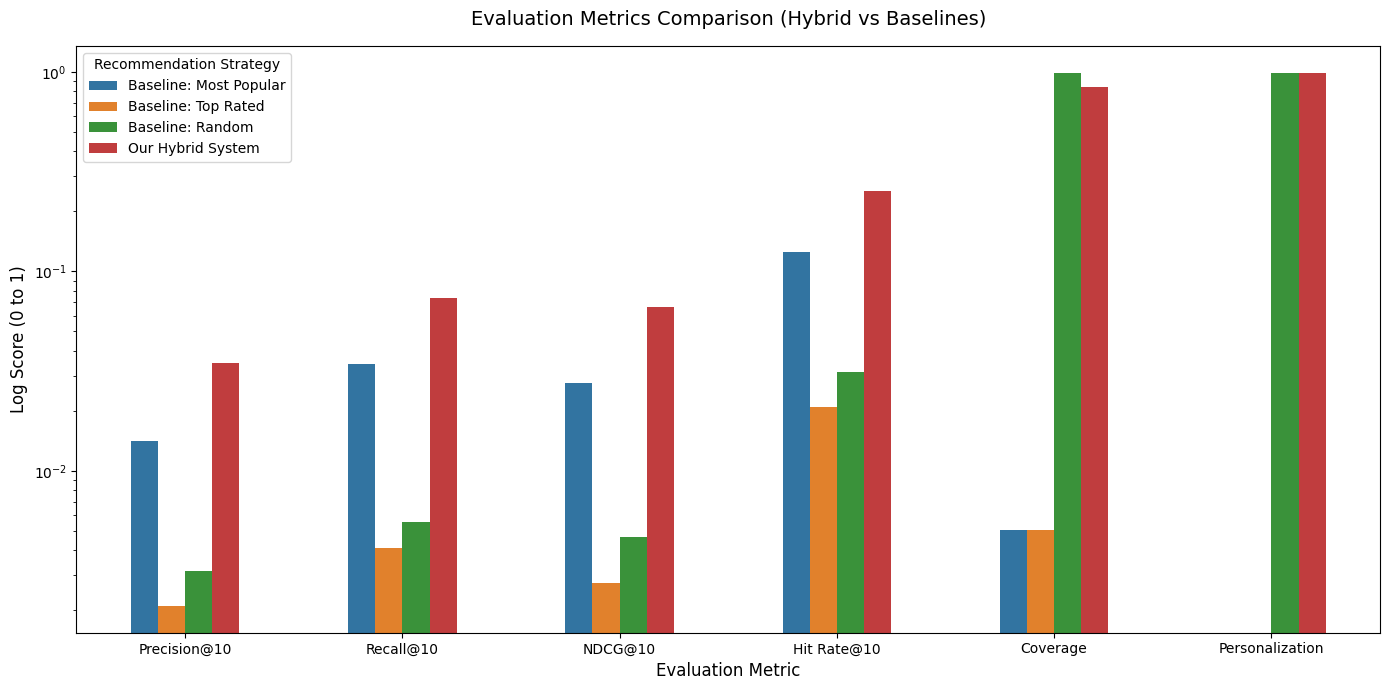

In [214]:
# Build the dataframe using the raw float values from the dictionaries
metrics_df = pd.DataFrame({
    'Metric': list(hybrid_metrics.keys()),
    'Baseline: Most Popular': list(popular_metrics.values()),
    'Baseline: Top Rated': list(top_rated_metrics.values()),
    'Baseline: Random': list(random_metrics.values()),
    'Our Hybrid System': list(hybrid_metrics.values()),
})

# Melt the dataframe for seaborn plotting
metrics_df_melted = metrics_df.melt(id_vars='Metric', var_name='Model', value_name='Score')

# Set up the plot
plt.figure(figsize=(14, 7))  # Made slightly wider to accommodate more bars
sns.barplot(data=metrics_df_melted, x='Metric', y='Score', hue='Model', width=0.5)

# Add titles and labels
plt.title('Evaluation Metrics Comparison (Hybrid vs Baselines)', fontsize=14, pad=15)
plt.ylabel('Log Score (0 to 1)', fontsize=12)
plt.xlabel('Evaluation Metric', fontsize=12)

# set y to log
plt.yscale('log')

# Move the legend outside the plot area so it doesn't overlap the bars
plt.legend(title='Recommendation Strategy', loc='upper left')

# Ensure nothing gets cut off when displaying/saving
plt.tight_layout()
plt.show()

## DEMO: warm users

In [210]:
def evaluate_specific_users(recommend_func, user_list, k=10):
    precision_scores, recall_scores, ndcg_scores, hit_scores = [], [], [], []
    for user_id in user_list:
        user_test = test_ratings[test_ratings['User-ID'] == user_id]
        relevant_items = set(user_test['ISBN'].values)
        if not relevant_items:
            continue
        recommended_items = recommend_func(user_id, n=k)
        recommended_set = set(recommended_items)
        if len(recommended_items) > 0:
            precision_scores.append(len(recommended_set & relevant_items) / len(recommended_items))
        recall_scores.append(len(recommended_set & relevant_items) / len(relevant_items))
        hit_scores.append(1.0 if len(recommended_set & relevant_items) > 0 else 0.0)
        ndcg_scores.append(calculate_ndcg(recommended_items, relevant_items, k))
    return {
        f'Precision@{k}': np.mean(precision_scores) if precision_scores else 0,
        f'Recall@{k}': np.mean(recall_scores) if recall_scores else 0,
        f'NDCG@{k}': np.mean(ndcg_scores) if ndcg_scores else 0,
        f'Hit Rate@{k}': np.mean(hit_scores) if hit_scores else 0
    }

user_rating_counts = train_ratings['User-ID'].value_counts()
test_user_ids = test_ratings['User-ID'].unique()
valid_warm_users = [u for u in user_rating_counts[user_rating_counts > COLD_START_THRESHOLD].index if u in test_user_ids]
demo_warm_users = valid_warm_users[:5]

print("\n" + "="*80)
print("STEP 5: SYSTEM DEMONSTRATION (5 WARM USERS)")
print("="*80)

for user_id in demo_warm_users:
    print("\n" + "-"*60)
    print(f"RECOMMENDATIONS FOR USER {user_id} (WARM USER)")
    print("-" * 60)
    
    user_info = users_sampled[users_sampled['User-ID'] == user_id].iloc[0]
    print(f"Demographics: Age {user_info['Age']}, Country: {user_info['Country']}")
    
    history = train_ratings[train_ratings['User-ID'] == user_id]
    print(f"Training History: {len(history)} books rated.")
    
    # --- ORGANIC SAMPLING LOGIC ---
    good_history = history[history['Book-Rating'] >= 8]
    if len(good_history) >= 5:
        display_history = good_history.sample(5, random_state=42) # organic mix of 8s, 9s, 10s
    else:
        display_history = history.nlargest(5, 'Book-Rating') # fallback if they don't have enough >= 8
        
    print("\n[User's Favorites in History]")
    for _, row in display_history.iterrows():
        if row['ISBN'] in books_sampled['ISBN'].values:
            b = books_sampled[books_sampled['ISBN'] == row['ISBN']].iloc[0]
            print(f"  - '{b['Book-Title']}' by {b['Book-Author']} ({int(b['Year-Of-Publication'])}) [Rated: {row['Book-Rating']}/10]")

    print("\n[System Recommendations (Top 5)]")
    recs = recommend_books(user_id, n=5)
    for idx, isbn in enumerate(recs, 1):
        if isbn in books_sampled['ISBN'].values:
            b = books_sampled[books_sampled['ISBN'] == isbn].iloc[0]
            print(f"  {idx}. '{b['Book-Title']}' by {b['Book-Author']} ({int(b['Year-Of-Publication'])})")

# --- LOCAL PERFORMANCE COMPARISON TABLE ---
print("\n" + "="*80)
print("PERFORMANCE COMPARISON FOR THESE 5 DEMO USERS")
print("="*80)

demo_hybrid_metrics = evaluate_specific_users(recommend_books, demo_warm_users, k=10)
demo_baseline_metrics = evaluate_specific_users(recommend_baseline, demo_warm_users, k=10)

comparison_df = pd.DataFrame({
    'Metric': ['Precision@10', 'Recall@10', 'NDCG@10', 'Hit Rate@10'],
    'Our Hybrid System': [demo_hybrid_metrics['Precision@10'], demo_hybrid_metrics['Recall@10'], demo_hybrid_metrics['NDCG@10'], demo_hybrid_metrics['Hit Rate@10']],
    'Baseline (Most Popular)': [demo_baseline_metrics['Precision@10'], demo_baseline_metrics['Recall@10'], demo_baseline_metrics['NDCG@10'], demo_baseline_metrics['Hit Rate@10']]
})
print(comparison_df.to_string(index=False))


STEP 5: SYSTEM DEMONSTRATION (5 WARM USERS)

------------------------------------------------------------
RECOMMENDATIONS FOR USER 16795 (WARM USER)
------------------------------------------------------------
Demographics: Age 47.0, Country: usa
Training History: 179 books rated.

[User's Favorites in History]
  - 'Dolores Claiborne' by Stephen King (2004) [Rated: 8/10]
  - 'The Secret Life Of Bees' by Sue Monk Kidd (2002) [Rated: 10/10]
  - 'Icy Sparks' by Gwyn Hyman Rubio (2001) [Rated: 9/10]
  - 'Blessings' by Anna Quindlen (2002) [Rated: 8/10]
  - 'Old Man And The Sea' by Ernest Hemingway (1995) [Rated: 8/10]

[System Recommendations (Top 5)]
  1. 'We Were The Mulvaneys' by Joyce Carol Oates (1996)
  2. 'I Know This Much Is True' by Wally Lamb (1999)
  3. 'Tis: A Memoir' by Frank Mccourt (2000)
  4. 'False Memory' by Dean R. Koontz (2000)
  5. 'Rose Madder' by Stephen King (2004)

------------------------------------------------------------
RECOMMENDATIONS FOR USER 95359 (WARM US

## DEMO: cold users

In [ ]:
valid_cold_users = [u for u in user_rating_counts[user_rating_counts <= COLD_START_THRESHOLD].index if u in test_user_ids]
demo_cold_users = valid_cold_users[:3]

print("\n" + "="*80)
print("STEP 6: BONUS - COLD-START DEMONSTRATION (3 USERS)")
print("="*80)

for user_id in demo_cold_users:
    print("\n" + "-"*60)
    print(f"RECOMMENDATIONS FOR USER {user_id} (COLD-START USER)")
    print("-" * 60)
    
    user_info = users_sampled[users_sampled['User-ID'] == user_id].iloc[0]
    print(f"Demographics: Age {user_info['Age']}, Country: {user_info['Country']}")
    
    history = train_ratings[train_ratings['User-ID'] == user_id]
    print(f"Training History: {len(history)} books rated.")
    
    if len(history) > 0:
        print("\n[User's Known History]")
        # --- ORGANIC SAMPLING LOGIC FOR COLD START ---
        display_history = history.sample(min(len(history), 3), random_state=42)
        for _, row in display_history.iterrows():
            if row['ISBN'] in books_sampled['ISBN'].values:
                b = books_sampled[books_sampled['ISBN'] == row['ISBN']].iloc[0]
                print(f"  - '{b['Book-Title']}' by {b['Book-Author']} ({int(b['Year-Of-Publication'])}) [Rated: {row['Book-Rating']}/10]")
    else:
        print("\n[User's Known History]")
        print("  - No training history available.")
    
    print("\n[System Recommendations (Top 5)]")
    recs = recommend_books(user_id, n=5)
    for idx, isbn in enumerate(recs, 1):
        if isbn in books_sampled['ISBN'].values:
            b = books_sampled[books_sampled['ISBN'] == isbn].iloc[0]
            print(f"  {idx}. '{b['Book-Title']}' by {b['Book-Author']} ({int(b['Year-Of-Publication'])})")


STEP 6: BONUS - COLD-START DEMONSTRATION (3 USERS)

------------------------------------------------------------
RECOMMENDATIONS FOR USER 1903 (COLD-START USER)
------------------------------------------------------------
Demographics: Age 36.0, Country: taiwan
Training History: 3 books rated.

[User's Known History]
  - 'Ender'S Game (Ender Wiggins Saga (Paperback))' by Orson Scott Card (1994) [Rated: 10/10]
  - 'Naked' by David Sedaris (1998) [Rated: 10/10]
  - 'Lullaby: A Novel' by Chuck Palahniuk (2003) [Rated: 2/10]

[System Recommendations (Top 5)]
  1. 'Holidays On Ice : Stories' by David Sedaris (1998)
  2. 'Naked' by David Sedaris (1997)
  3. 'Shadow Of The Hegemon (Ender Wiggins Saga (Paperback))' by Orson Scott Card (2001)
  4. 'Xenocide (Ender Wiggins Saga (Paperback))' by Orson Scott Card (1992)
  5. 'Speaker For The Dead (Ender Wiggins Saga (Paperback))' by Orson Scott Card (1994)

------------------------------------------------------------
RECOMMENDATIONS FOR USER 6424